# NRI Table Counties EDA

Dataset: `data/fema/NRI_Table_Counties.csv`

This notebook performs exploratory data analysis for structure, completeness, date coverage, geographic coverage, and high-signal distributions. Run cells from top to bottom after installing the project dependencies.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent.parent


DATA_PATH = ROOT / "data" / "fema" / "NRI_Table_Counties.csv"
DATA_PATH

WindowsPath('C:/Users/kenny/Data Science Projects/quoll-intelligence/data/fema/NRI_Table_Counties.csv')

## Load And Inspect

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
display(df.head())
display(df.shape)
display(df.dtypes.value_counts().to_frame("column_count"))

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,BUILDVALUE,AGRIVALUE,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB,EAL_VALP,EAL_VALPE,EAL_VALA,ALR_VALB,ALR_VALP,ALR_VALA,ALR_NPCTL,ALR_VRA_NPCTL,SOVI_SCORE,SOVI_RATNG,SOVI_SPCTL,RESL_SCORE,RESL_RATNG,RESL_SPCTL,RESL_VALUE,CRF_VALUE,AVLN_EVNTS,AVLN_AFREQ,AVLN_EXP_AREA,AVLN_EXPB,AVLN_EXPP,AVLN_EXPPE,AVLN_EXPT,AVLN_HLRB,AVLN_HLRP,AVLN_HLRR,AVLN_EALB,AVLN_EALP,AVLN_EALPE,AVLN_EALT,AVLN_EALS,AVLN_EALR,AVLN_ALRB,AVLN_ALRP,AVLN_ALR_NPCTL,AVLN_RISKV,AVLN_RISKS,AVLN_RISKR,...,VLCN_EALR,VLCN_ALRB,VLCN_ALRP,VLCN_ALR_NPCTL,VLCN_RISKV,VLCN_RISKS,VLCN_RISKR,WFIR_EVNTS,WFIR_AFREQ,WFIR_EXP_AREA,WFIR_EXPB,WFIR_EXPP,WFIR_EXPPE,WFIR_EXPA,WFIR_EXPT,WFIR_HLRB,WFIR_HLRP,WFIR_HLRA,WFIR_HLRR,WFIR_EALB,WFIR_EALP,WFIR_EALPE,WFIR_EALA,WFIR_EALT,WFIR_EALS,WFIR_EALR,WFIR_ALRB,WFIR_ALRP,WFIR_ALRA,WFIR_ALR_NPCTL,WFIR_RISKV,WFIR_RISKS,WFIR_RISKR,WNTW_EVNTS,WNTW_AFREQ,WNTW_EXP_AREA,WNTW_EXPB,WNTW_EXPP,WNTW_EXPPE,WNTW_EXPA,WNTW_EXPT,WNTW_HLRB,WNTW_HLRP,WNTW_HLRA,WNTW_HLRR,WNTW_EALB,WNTW_EALP,WNTW_EALPE,WNTW_EALA,WNTW_EALT,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,1,C01001,Alabama,AL,1,Autauga,County,1,1001,58764,1.024141e+10,27630646.0,610.470508,2.051090e+07,57.569975,Relatively Low,57.569975,59.870050,Relatively Low,56.716418,1.975657e+07,1.385350e+07,0.412821,5.655652e+06,2.474187e+05,0.001518,0.000007,0.010052,49.721535,45.515267,38.040712,Relatively Low,9.701493,55.120865,Relatively Moderate,76.119403,2.494860,1.038181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,...,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,0.000569,23.109638,1.367163e+09,10559.815261,1.446695e+11,4.004713e+06,1.460406e+11,0.1,0.000117,0.007141,Very Low,3.002976e+04,0.000454,6216.075404,16.406169,3.626224e+04,47.105598,Very Low,0.000003,7.721192e-09,5.937671e-07,41.348601,3.764677e+04,45.737913,Very Low,26.00000,1.368421,610.470508,1.024141e+10,58764.0,8.050668e+11,27630646.0,8.153358e+11,1.606919e-07,3.977501e-09,1.040342e-06,Very Low,2252.026376,0.000320,4381.894510,39.336299,6673.257184,13.095975,Very Low,2.198943e-07,5.442896e-09,1.423647e-06,27.739938,6928.050098,9.038829,Very Low,December 2025
1,2,C01003,Alabama,AL,1,Baldwin,County,3,1003,231365,5.160230e+10,155012958.0,2047.738775,2.532687e+08,96.723919,Relatively High,96.723919,96.627475,Relatively High,97.014925,2.373912e+08,2.084471e+08,1.932259,2.647194e+07,2.472096e+06,0.004535,0.000008,0.017902,97.741337,97.105598,44.243003,Relatively Moderate,9.701493,93.002545,Very High,100.000000,2.643844,1.066884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,...,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,0.003136,61.616328,4.042928e+09,43778.385011,5.997639e+11,2.252990e+07,6.038293e+11,0.1,0.000117,0.007141,Relatively Moderate,1.282742e+06,0.015847,217101.319534,470.262851,1.500314e+06,91.125954,Relatively Moderate,0.000025,6.849269e-08,3.033700e-06,67.938931,1.600660e+06,90.776081,Relatively Moderate,10.57465,0.686211,1674.843955,5.160230e+10,231365.0,3.169700e+12,155012958.0,3.221458e+12,4.162683e-07,3.950781e-08,1.307012e-06,Very Low,12111.808444,0.005402,74013.964868,119.903789,86245.677101,61.114551,Relatively Moderate,2.347145e-07,2.335046e-08,7.735082e-07,16.934985,92014.103472,59.325271,Relatively Low,December 2025
2,3,C01005,Alabama,AL,1,Barbour,County,5,1005,25160,5.441822e+09,135914589.0,913.646511,1.599858e+07,48.123410,Relatively Low,48.123410,30.538366,Very Low,25.373134,8.923878e+06,5.555196e+06,0.178337,2.443220e+06,9.254627e+05,0.001146,0.000007,0.007644,23.700495,64.949109,96.374046,Very High,88.805970,11.164122,Very Low,4.477612,2.328449,1.792783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,N

(3232, 465)

,column_count
float64,396
object,64
int64,5


## Completeness

In [3]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    missing = frame.isna().sum()
    unique_values = []
    for col in frame.columns:
        try:
            unique_values.append(frame[col].nunique(dropna=True))
        except TypeError:
            unique_values.append(np.nan)
    return (
        pd.DataFrame({
            "missing_count": missing,
            "missing_pct": missing / len(frame) * 100,
            "dtype": frame.dtypes.astype(str),
            "unique_values": unique_values,
        })
        .sort_values("missing_pct", ascending=False)
    )


missing_summary(df).head(40)

,missing_count,missing_pct,dtype,unique_values
CFLD_EVNTS,3232,100.000000,float64,0
ERQK_EVNTS,3232,100.000000,float64,0
WFIR_EVNTS,3232,100.000000,float64,0
TSUN_RISKV,3167,97.988861,float64,65
TSUN_RISKS,3167,97.988861,float64,65
LNDS_EVNTS,3154,97.586634,float64,67
TSUN_EALPE,3113,96.318069,float64,61
TSUN_HLRB,3113,96.318069,float64,118
TSUN_EXPT,3113,96.318069,float64,119
TSUN_HLRP,3113,96.318069,float64,61


## Core Risk Measures

In [4]:
core_cols = [
    "STATE", "STATEABBRV", "COUNTY", "STCOFIPS", "POPULATION", "BUILDVALUE", "AGRIVALUE", "AREA",
    "RISK_VALUE", "RISK_SCORE", "RISK_RATNG", "EAL_SCORE", "EAL_RATNG", "EAL_VALT",
    "SOVI_SCORE", "SOVI_RATNG", "RESL_SCORE", "RESL_RATNG",
]
core = df[[c for c in core_cols if c in df.columns]].copy()
display(core.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
STATE,3232,56,Texas,254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATEABBRV,3232,56,TX,254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTY,3232,1924,Washington,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STCOFIPS,3232.0,NaN,NaN,NaN,31493.51578,16410.813172,1001.0,19034.5,30032.0,46121.5,78030.0
POPULATION,3232.0,NaN,NaN,NaN,103564.760829,330827.641456,64.0,10930.25,25791.5,67123.0,10005712.0
BUILDVALUE,3232.0,NaN,NaN,NaN,21623592559.887684,61654028029.553772,56941548.0,2790497237.75,6239465591.5,15573727848.5,1703724947920.0
AGRIVALUE,3232.0,NaN,NaN,NaN,154970301.19245,316638552.739114,0.0,23808075.5,77158632.0,181493709.75,7394104194.0
AREA,3232.0,NaN,NaN,NaN,1190.954025,3789.21332,2.067115,438.667502,645.829416,986.62645,149363.640223
RISK_VALUE,3144.0,NaN,NaN,NaN,51500133.487944,219202408.27192,54920.459871,8825243.722176,16925905.010101,35591427.710126,9180158357.595432
RISK_SCORE,3144.0,NaN,NaN,NaN,50.015903,28.872104,0.031807,25.023855,50.015903,75.007952,100.0


In [5]:
rank_cols = [c for c in ["STATEABBRV", "COUNTY", "STCOFIPS", "POPULATION", "RISK_VALUE", "RISK_SCORE", "RISK_RATNG", "EAL_VALT", "SOVI_SCORE", "RESL_SCORE"] if c in df.columns]
df[rank_cols].sort_values("RISK_SCORE", ascending=False).head(25)

,STATEABBRV,COUNTY,STCOFIPS,POPULATION,RISK_VALUE,RISK_SCORE,RISK_RATNG,EAL_VALT,SOVI_SCORE,RESL_SCORE
205,CA,Los Angeles,6037,10005712,9.180158e+09,100.000000,Very High,7.601846e+09,55.375318,13.549618
603,IL,Cook,17031,5272775,2.957063e+09,99.968193,Very High,2.424304e+09,61.736641,73.282443
2616,TX,Harris,48201,4726200,2.947094e+09,99.936387,Very High,2.217702e+09,67.938931,17.875318
219,CA,Riverside,6065,2416838,2.304891e+09,99.904580,Very High,2.265638e+09,33.333333,13.040712
104,AZ,Maricopa,4013,4418836,2.118483e+09,99.872774,Very High,2.195562e+09,27.099237,18.034351
222,CA,San Bernardino,6071,2179979,2.104012e+09,99.840967,Very High,2.075100e+09,33.206107,20.069975
216,CA,Orange,6059,3183647,1.822512e+09,99.809160,Very High,1.926467e+09,24.936387,16.316794
187,CA,Alameda,6001,1678284,1.776525e+09,99.777354,Very High,1.884810e+09,27.480916,91.157761
229,CA,Santa Clara,6085,1934625,1.686687e+09,99.745547,Very High,1.965274e+09,17.239186,72.614504
223,CA,San Diego,6073,3295981,1.462271e+09,99.713740,Very High,1.539181e+09,24.809160,8.301527


## Distributions And Ratings

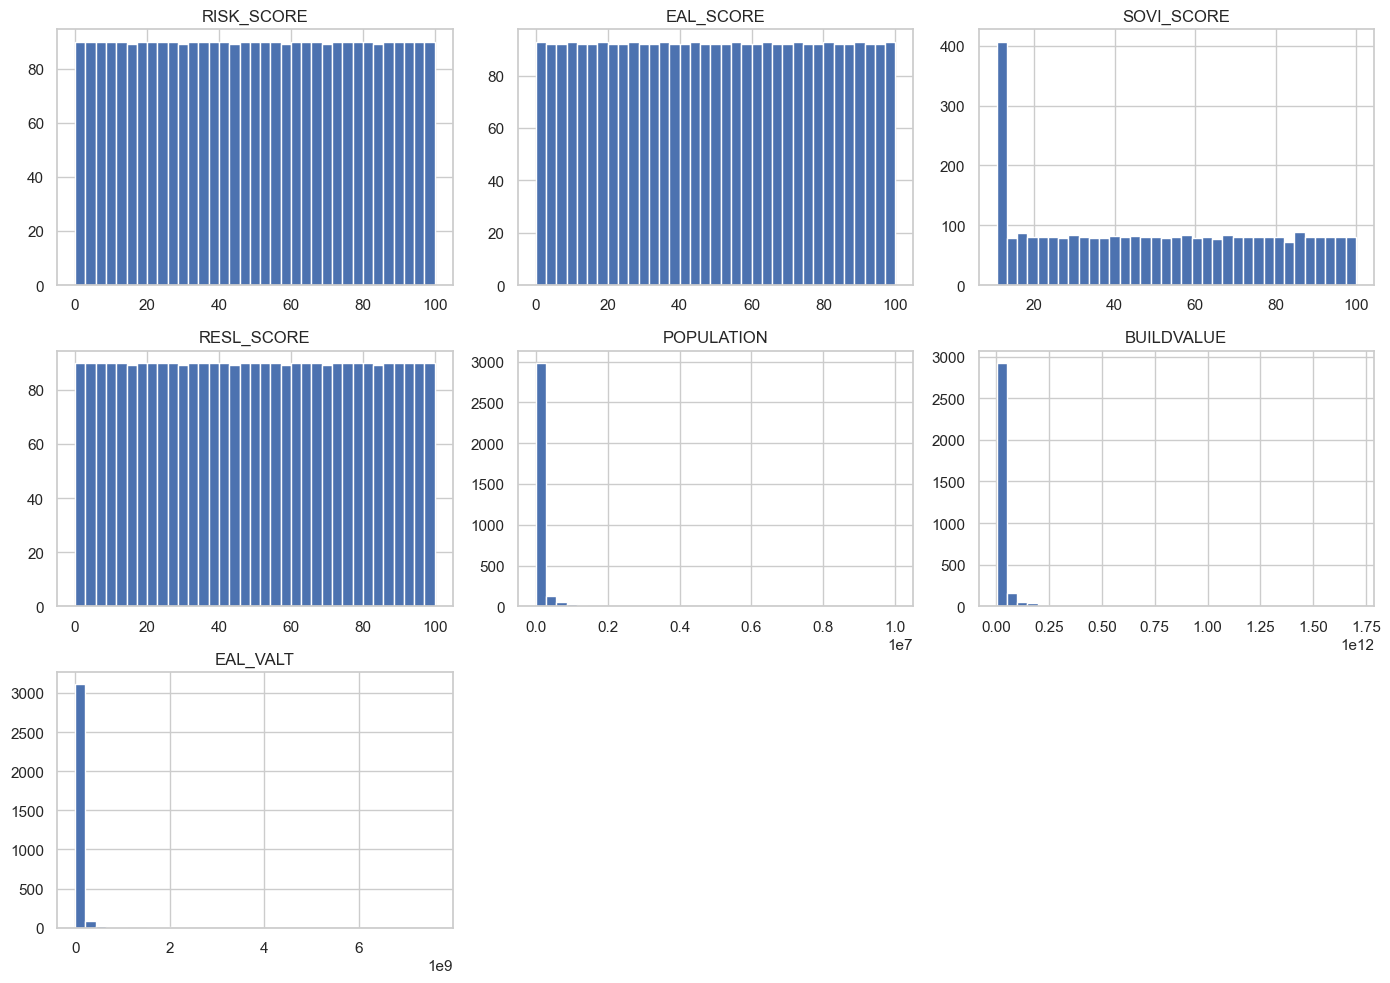

In [6]:
numeric_focus = [c for c in ["RISK_SCORE", "EAL_SCORE", "SOVI_SCORE", "RESL_SCORE", "POPULATION", "BUILDVALUE", "EAL_VALT"] if c in df.columns]
df[numeric_focus].hist(figsize=(14, 10), bins=35)
plt.tight_layout()
plt.show()

In [7]:
rating_cols = [c for c in ["RISK_RATNG", "EAL_RATNG", "SOVI_RATNG", "RESL_RATNG"] if c in df.columns]
for col in rating_cols:
    display(df[col].value_counts(dropna=False).to_frame("count"))

,count
RISK_RATNG,
Very Low,1345
Relatively Low,1200
Relatively Moderate,420
Relatively High,162
Insufficient Data,88
Very High,17


,count
EAL_RATNG,
Very Low,1604
Relatively Low,1125
Relatively Moderate,350
Relatively High,142
Very High,11


,count
SOVI_RATNG,
Relatively Low,632
Relatively High,630
Very High,629
Relatively Moderate,628
Very Low,625
Data Unavailable,88


,count
RESL_RATNG,
Relatively Moderate,629
Very High,629
Relatively Low,629
Relatively High,629
Very Low,628
Data Unavailable,88


## Hazard-Level Signals

,mean_risk_score
TSUN_RISKS,50.769231
AVLN_RISKS,50.073099
ISTM_RISKS,50.016661
TRND_RISKS,50.015903
LTNG_RISKS,50.015903
LNDS_RISKS,50.015903
WFIR_RISKS,50.015893
IFLD_RISKS,50.015802
ERQK_RISKS,50.015620
HAIL_RISKS,50.014173


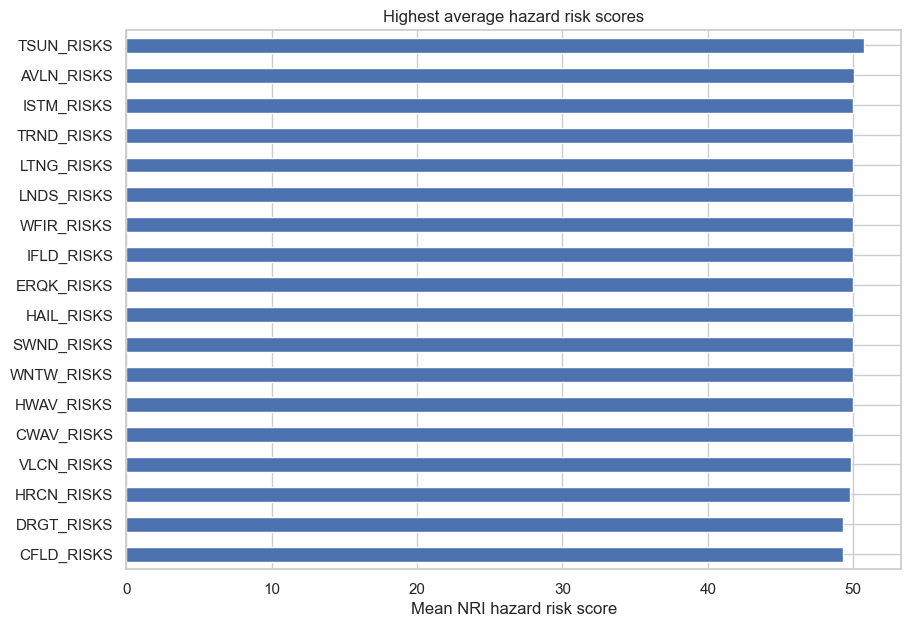

In [8]:
hazard_risk_cols = [c for c in df.columns if c.endswith("_RISKS")]
hazard_scores = df[hazard_risk_cols].mean(numeric_only=True).sort_values(ascending=False)
display(hazard_scores.to_frame("mean_risk_score").head(25))

ax = hazard_scores.head(20).sort_values().plot(kind="barh", figsize=(10, 7), title="Highest average hazard risk scores")
ax.set_xlabel("Mean NRI hazard risk score")
plt.show()

In [9]:
hazard_event_cols = [c for c in df.columns if c.endswith("_EVNTS")]
event_totals = df[hazard_event_cols].sum(numeric_only=True).sort_values(ascending=False)
display(event_totals.head(25).to_frame("total_events"))

,total_events
LTNG_EVNTS,3.905888e+08
DRGT_EVNTS,2.494191e+06
WNTW_EVNTS,6.450640e+05
HAIL_EVNTS,4.117072e+05
SWND_EVNTS,3.328450e+05
HWAV_EVNTS,2.870519e+05
CWAV_EVNTS,1.715678e+05
ISTM_EVNTS,1.317600e+05
IFLD_EVNTS,1.190960e+05
LNDS_EVNTS,7.163800e+04


## Relationships

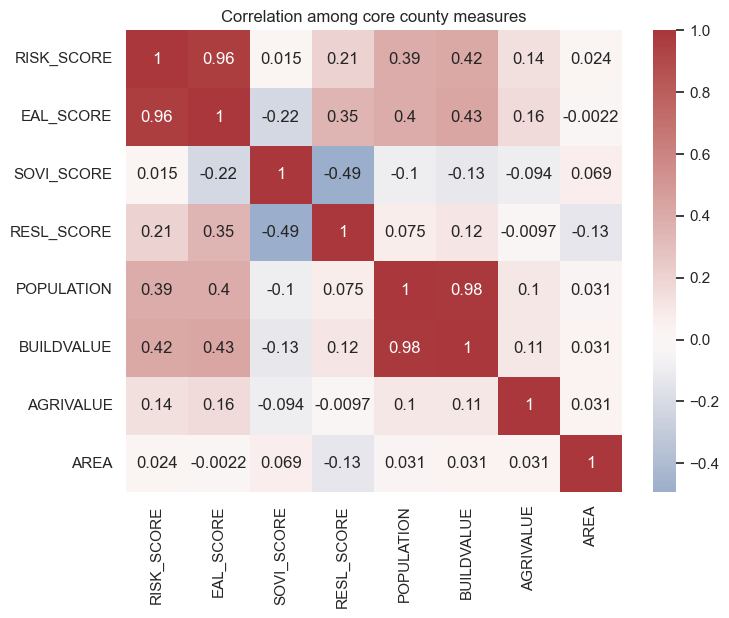

,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,POPULATION,BUILDVALUE,AGRIVALUE,AREA
RISK_SCORE,1.000000,0.963294,0.015260,0.205934,0.392614,0.421148,0.138992,0.024372
EAL_SCORE,0.963294,1.000000,-0.224202,0.346960,0.396571,0.426789,0.158907,-0.002201
SOVI_SCORE,0.015260,-0.224202,1.000000,-0.493893,-0.101069,-0.130364,-0.093918,0.068690
RESL_SCORE,0.205934,0.346960,-0.493893,1.000000,0.074664,0.115813,-0.009658,-0.133135
POPULATION,0.392614,0.396571,-0.101069,0.074664,1.000000,0.983836,0.102178,0.031293
BUILDVALUE,0.421148,0.426789,-0.130364,0.115813,0.983836,1.000000,0.106716,0.031458
AGRIVALUE,0.138992,0.158907,-0.093918,-0.009658,0.102178,0.106716,1.000000,0.031418
AREA,0.024372,-0.002201,0.068690,-0.133135,0.031293,0.031458,0.031418,1.000000


In [10]:
corr_cols = [c for c in ["RISK_SCORE", "EAL_SCORE", "SOVI_SCORE", "RESL_SCORE", "POPULATION", "BUILDVALUE", "AGRIVALUE", "AREA"] if c in df.columns]
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="vlag", center=0)
plt.title("Correlation among core county measures")
plt.show()
corr